In [ ]:
'''
2024.10.24 - Research Gate - Emile-Geay - Regime shifts in Holocene paleohydrology as recorded by Asian Speleothems - https://www.researchgate.net/publication/383519557_Regime_shifts_in_Holocene_paleohydrology_as_recorded_by_Asian_Speleothems

Although a pre-print for AGU, it emphasizes that the regional chinese speleothem records do not show a global 4.2 k event, it seems to be more regional.
I searched for 4.2 event at Wikipedia https://en.wikipedia.org/wiki/4.2-kiloyear_event with good references: 

-An Andean ice-core record of a Middle Holocene mega-drought in North Africa and Asia 
https://www.cambridge.org/core/journals/annals-of-glaciology/article/an-andean-icecore-record-of-a-middle-holocene-megadrought-in-north-africa-and-asia/45FF2EF2D92697EB0F93A640C3FF5E5E

-Massive drought or myth? Scientists spar over an ancient climate event behind our new geological age
https://www.science.org/content/article/massive-drought-or-myth-scientists-spar-over-ancient-climate-event-behind-our-new

-Mawmluh Cave, India downloaded records from NOAA to compare with Dino

'''

In [33]:
import pyleoclim as pyleo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [15]:
## Mawmluh Cave, India 
## 25°15'44"N, 91°52'54"E, 1290 m
mawmluh2012 = pd.read_table(r'..\data\MawmluhCave\mawmluh2012.txt', comment='#', delim_whitespace=True)
ts_mawm2012 = pyleo.Series(
    time=mawmluh2012['YearBP'],
    value=mawmluh2012['d18O'], 
    time_name='Age',
    time_unit='BP',
    value_name=r'$\delta^{18}$O',
    value_unit='‰ VPDB',
    label="Mawmluh Cave"
)

## Dino Cave, Ecuador
## 
din2 = pd.read_table('..\data\GDD1_d18O_CopraSpline_2mm.txt')
ts_din2 = pyleo.Series(
    time =  din2.iloc[:, 0] , 
    value = din2.iloc[:, 1],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = r'$\delta^{18}$O',
    value_unit = '‰ VPDB',
    label = 'Dino cave', verbose=False)



Time axis values sorted in ascending order


C:\Users\danny\AppData\Local\Temp\ipykernel_16204\1669645339.py:4: UserWarning: auto_time_params is not specified. Currently default behavior sets this to True, which might modify your supplied time metadata.  Please set to False if you want a different behavior.
  ts_mawm2012 = pyleo.Series(


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [Years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>)

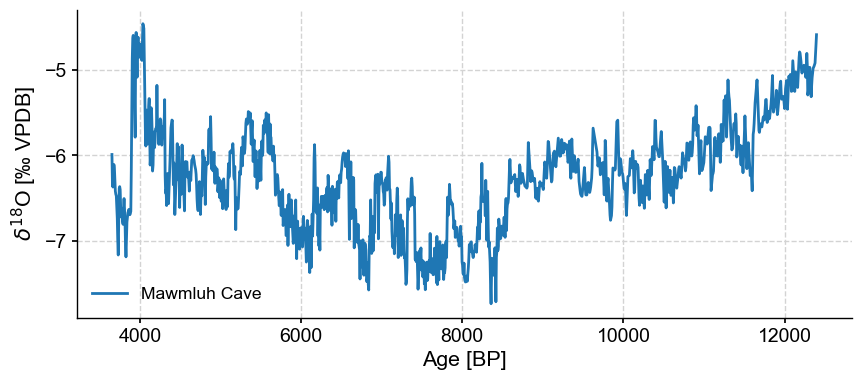

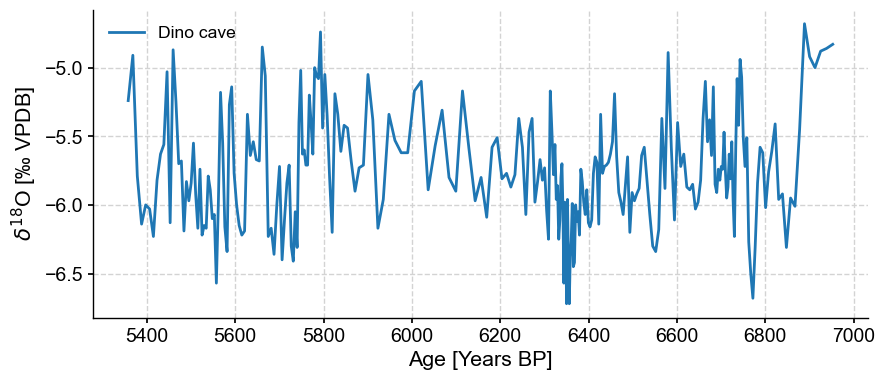

In [16]:
ts_mawm2012.plot()
ts_din2.plot()



<Axes: xlabel='Age [Years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>

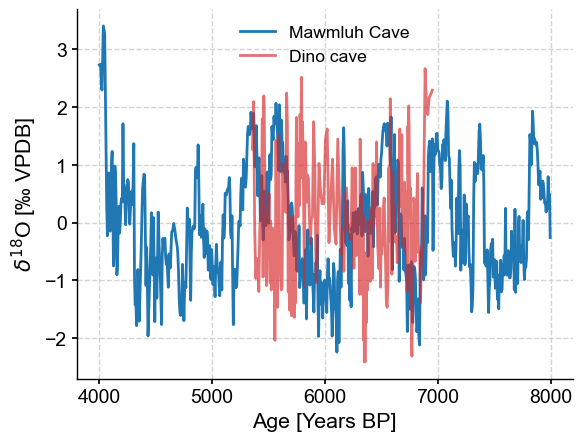

In [51]:
fig, ax = plt.subplots()
ts_mawm2012.sel(time=slice(4000,8000)).detrend(method='linear').standardize().plot(ax=ax)
ts_din2.standardize().plot(ax=ax, alpha=0.65, color='tab:red')

## Reversed Y-axis

<Axes: xlabel='Age [Years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>

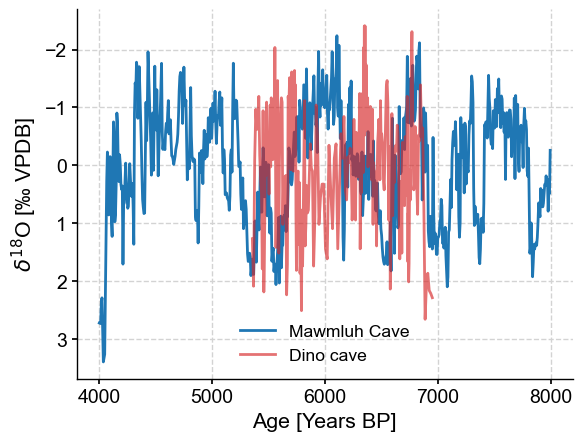

In [52]:
fig, ax = plt.subplots()
ts_mawm2012.sel(time=slice(4000,8000)).detrend(method='linear').standardize().plot(ax=ax, invert_yaxis=True)
ts_din2.standardize().plot(ax=ax, alpha=0.65, color='tab:red')


(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Dino cave scalogram (WWZ)'}, xlabel='Age [Years BP]', ylabel='Scale [Years BP]'>)

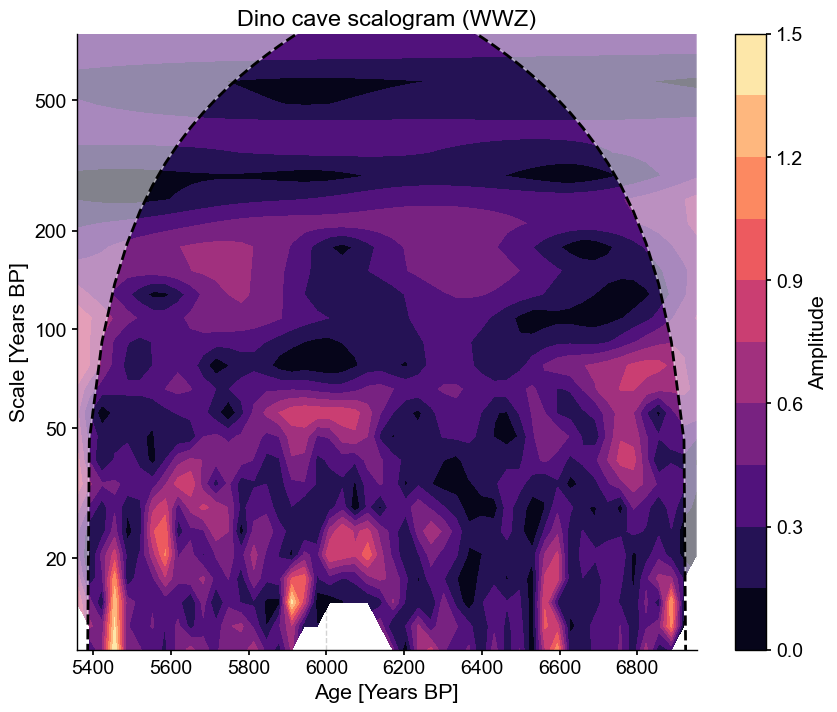

In [60]:
ts_din2.wavelet(method='wwz').plot()

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Dino cave scalogram (WWZ)'}, xlabel='Age [Years BP]', ylabel='Scale [Years BP]'>)

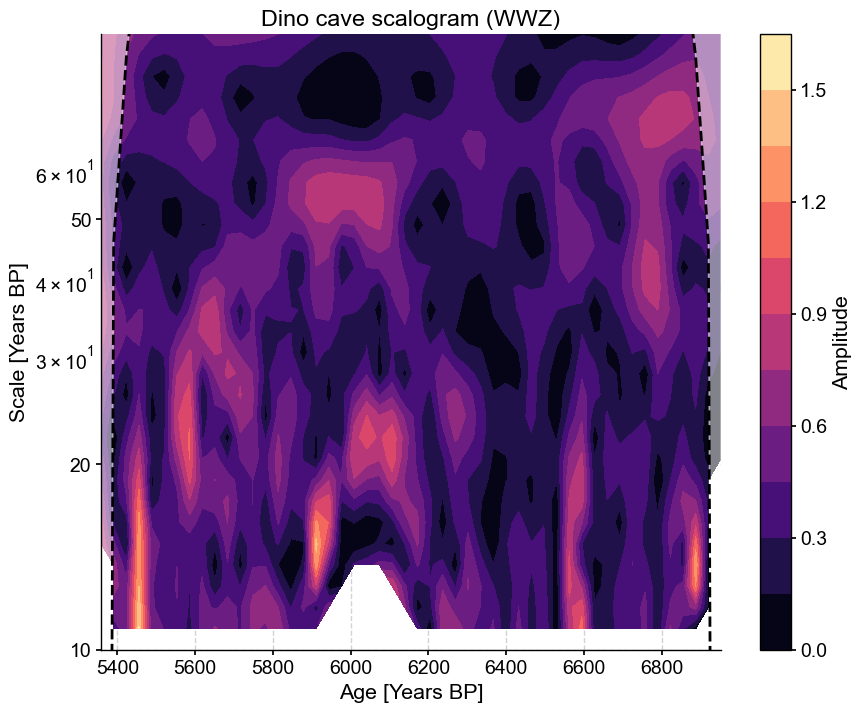

In [61]:
ts_din2.wavelet(method='wwz', freq_kwargs={'fmin':1/100,'fmax':1/10,'nf':30}).plot()